In [29]:
if "BrentScheme" not in locals():
  !pip install "git+https://github.com/perryGabriel/brent-scheme.git"
from brentscheme import *
import torch
from tqdm import trange
factory = SchemaFactory()
printer = SchemeDisplay()
manipulator = SchemeManipulator()
stepper = Stepper()
trainer = Trainer()

In [30]:
# printer.dump_tensors(scheme)

Figure form AlphaEvolve, screenshot from Matt Parker's video: https://www.youtube.com/watch?v=sGCmu7YKgPA

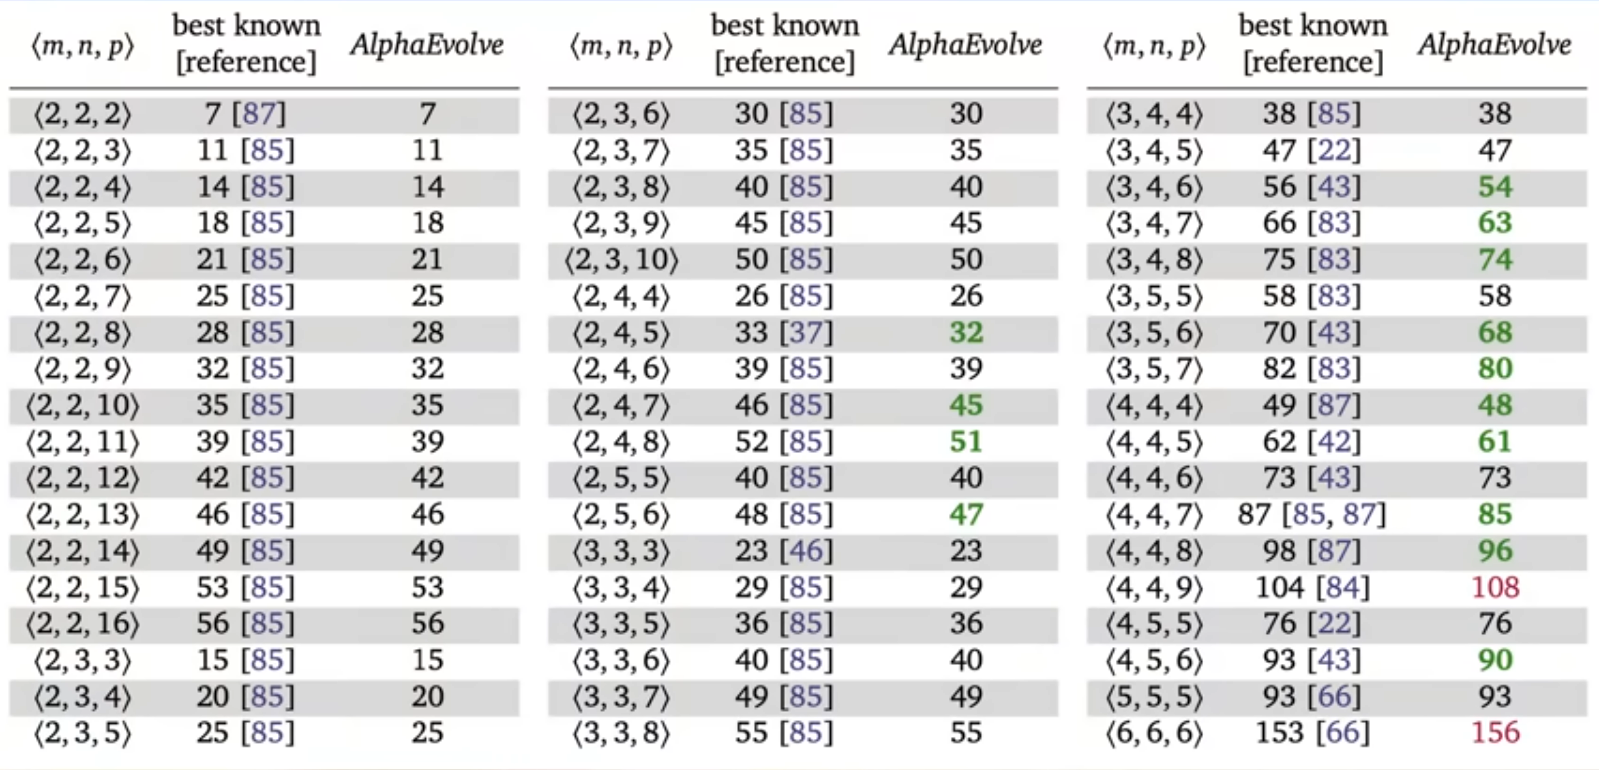

In [31]:
# TODO: turn the table into a callable function n,d,m -> smallest_known_solution; reorder if the general tranpose holds, and maybe try some factoring/tiling/composing dynamic programming magic for larger schemes.

In [32]:
#@title Parameters

n,d,m = 6,6,6
smallest_known_solution = 153

num_samples = lambda p: 15
# num_samples = lambda p: int(np.sqrt(p)/3)

start = smallest_known_solution - 15
end = n*d*m + 5

num_iters_per_optim = 20
batch_size = 2


In [33]:
#@title Estimate Upper Bound on Errors for each p
from tqdm import trange
errors = {}

try:
  for p in trange(start,end):
    if p not in errors:
      errors[p] = []
    for i in range(num_samples(p)):
      scheme = BrentScheme(n=n,d=d,m=m,p=p)
      for i in range(num_iters_per_optim):
        if p < smallest_known_solution and 10**printer.metrics(scheme).log10_L2 < 0.001:
          printer.dump_tensors(scheme)
        stepper.epoch_pseudoinverse(scheme, batch_size=batch_size)
        stepper.epoch(scheme, penalty=0.2, lr=5e-6, batch_size=batch_size) # fastest method
      errors[p].append([printer.metrics(scheme).log10_L1,printer.metrics(scheme).log10_L2,printer.metrics(scheme).log10_Linf])
except:
  pass

100%|██████████| 83/83 [1:58:34<00:00, 85.71s/it] 


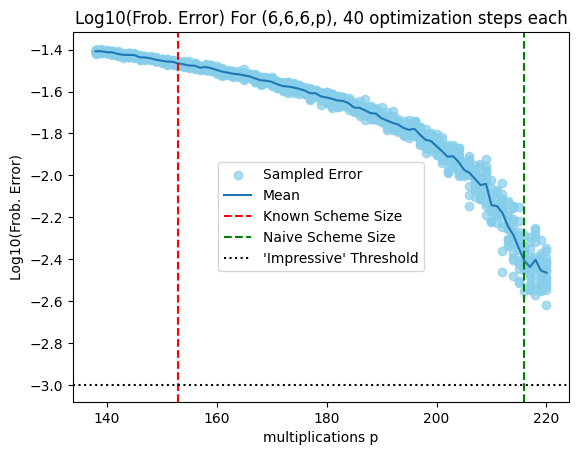

In [34]:
#@title Plot Results
import matplotlib.pyplot as plt
import numpy as np

means = [np.mean([error[1] for error in errors[p]]) for p in errors]
mins = [np.min([error[1] for error in errors[p]]) for p in errors]

# plt.figure(figsize=(10,8), dpi=100)

plt.title(f"Log10(Frob. Error) For ({n},{d},{m},p), {num_iters_per_optim*batch_size} optimization steps each")
plt.xlabel("multiplications p")
plt.ylabel("Log10(Frob. Error)")

# plt.plot([p for p in errors], mins, label="Upper Bound on Bet Error for p")
for p in range(start,start+len(errors)):
  plt.scatter([p]*len(errors[p]), [error[1] for error in errors[p]], alpha=0.7, color="skyblue")
plt.scatter([],[], alpha=0.7, color="skyblue", label="Sampled Error")
plt.plot([p for p in errors], means, label="Mean")
plt.axvline(x=smallest_known_solution, color='r', linestyle='--', label="Known Scheme Size")
plt.axvline(x=n*d*m, color='g', linestyle='--', label="Naive Scheme Size")
plt.axhline(y=-3, color='k', linestyle=':', label="'Impressive' Threshold")
plt.legend()

plt.savefig(f"{n}_{d}_{m}_p_in_{start}_{end}_error_plot")

plt.show()